<a href="https://colab.research.google.com/github/HenryZumaeta/py4cd_EPC2025/blob/main/C22/C22_Script01_VapnikChernonenkis_Regularizacion_LassoRidge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dimensión Vapnik-Chervonenkis (VC)

Definición: La dimensión VC de un conjunto de hipótesis H ($d_{vc}(H)$) se define como el máximo número de puntos que pueden ser etiquetados (o fragmentados /shattered) de todas las formas posibles en H.

Para un modelo de Regresión Lineal es un espacio de características de dimensi´n $d$ (con $d$ variable de entrada), el modelo tiene $d$ pesos más 1 sesgo (intercepto).

## Relevancia e Importancia

1. Cotas de Generalización
2. Complejidad de la muestra
3. El trade-off sesgo-varianza

## Usos y aplicaciones prácticas
1. Selección de características
2. Regularización (Ridge y Lasso)
3. Minimización del riesgo estructural
4. Detección de sobreajuste

## Limitaciones y Consideraciones Críticas
* Cotas pesimistas
* Distribuciuón de los datos
* Dimensión VC es para problemas de clasificación
* Alternativas modernas: Complejidad de Rademacher o normas matriciales




# Complejidad de Rademacher en una Regresión Lineal

+ Caso lineal con norma acotada: Consideremos la clase de funciones lineales, donde la norma del vector de pesos está acotada $(\|w\|_{2} \leq B)$ y los datos de entrada están acotados $(\|x\|_{2} \leq R)$

$$
R_{s}(F_{lineal}) \leq \frac{B \cdot R}{\sqrt {N}}
$$

## Relevancia e importancia
+ Dependencia en la distribución de los datos
+ Manejo de espacios infinitos
+ Cotas más ajustadas

## Usos y apliaciones prácticas
+ Justificación teóricas de la regularización
+ Normalización de características (Feature Scaling)
+ Selección de modelos e hiperparámetros

## Limitaciones
+ Costo computacional
+ Supuestos de acotamiento
+ Interpretabilidad

In [30]:
# Módulos y generación de datos (El escenario de ruido)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# La Clase Pipeline de sklearn
from sklearn.pipeline import Pipeline

# La Clase PolynomialFeature
from sklearn.preprocessing import PolynomialFeatures

# Regresión Lineal + Técnicas de Regularización
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Indicador de calidad: MSE
from sklearn.metrics import mean_squared_error

#
from sklearn.model_selection import train_test_split, GridSearchCV, KFold

# Generación de datos sintéticos
def generate_data(n_samples = 30, noise_std=0.1, random_state = 666):
    """
    Generación de datos sintéticos de la forma: y = sin(2*pi*x) + epsilon
    """
    np.random.seed(random_state)
    X = np.linspace(0,1, n_samples)
    y_true = np.sin(2*np.pi*X)
    y_noise = y_true + np.random.normal(0, noise_std, n_samples)
    return X, y_true, y_noise

# Crear datos y particionarlos
X, y_true, y_obs = generate_data(n_samples=300, noise_std = 0.10)
X_train, X_test, y_train, y_test = train_test_split(X, y_obs, test_size=0.4, random_state = 666)

# Formulacion matematica de una regresion lineal considerando una regularizacicon $L2$

En una regresion lineal

$$
\min_{\beta} \sum_{i = 1}^{n} (y_{i} - X_{i} \beta)^{2}
$$

Mediante Ridge (L2):

$$
\min_{\beta} \sum_{i = 1}^{n} (\|y_{i} - X_{i} \beta\|^{2} + \alpha \|\beta\|^2)
$$

Asi como una regresion lineal tiene una formula cerrada para el calculo de sus parametros, Ridge tambien tiene una solucion cerrada:

$$
\beta_{ridge} = (X^T X + \alpha I)^{-1}X^{T}y
$$


In [31]:
# Veamos la falla de la regresión lineal ordinaria: Demostremos que LinearRegresion
# con alta complejidad (polinomio de grado 15) viola el supuesto de generalización

# Definamos una variable para el grado del polinomio
degree_high = 15


# Consideremos implementar un pipeline de un modelo sin regularización
model_ols = Pipeline(
    [
        ("poly", PolynomialFeatures(degree = degree_high, include_bias=False)),
        ("linear", LinearRegression())
    ]
)

# Ajustemos este Pipeline
model_ols.fit(X_train.reshape(-1,1), y_train)

# Evaluación
y_train_pred_ols = model_ols.predict(X_train.reshape(-1,1))
y_test_pred_ols = model_ols.predict(X_test.reshape(-1,1))

mse_train_ols = mean_squared_error(y_train, y_train_pred_ols)
mse_test_ols = mean_squared_error(y_test, y_test_pred_ols)

# Mostremos resultados
print(f"Resultados OLS (Grado: {degree_high})")
print(f"MSE Train: {mse_train_ols} (Cercano a 0 → Ajuste Perfecto)")
print(f"MSE Test: {mse_test_ols} (Alto → Fallo de Generalización)")
print(f"Brecha Generalización: {mse_test_ols - mse_train_ols}")

# El problema (de acuerdo a los resultados) es que el ruido en test es
# independiente al ruido en entrenamiento

Resultados OLS (Grado: 15)
MSE Train: 0.009515797896920435 (Cercano a 0 → Ajuste Perfecto)
MSE Test: 0.01074420336185422 (Alto → Fallo de Generalización)
Brecha Generalización: 0.0012284054649337843


Norma L2 de los coeficientes 390371499.75939375


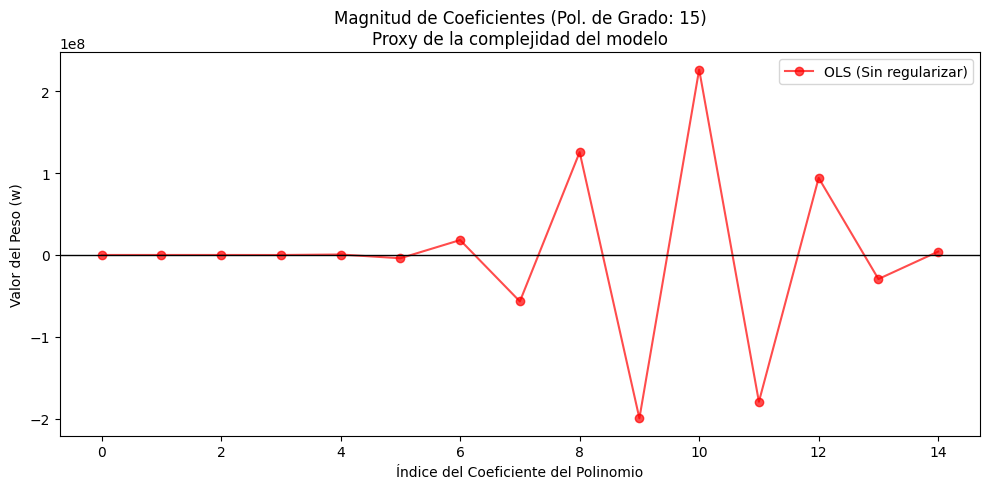

In [32]:
# Diagnostiquemos este problema de complejidad (Explosión de Coeficientes)
print(f"Norma L2 de los coeficientes {np.linalg.norm(model_ols.named_steps["linear"].coef_)}")

# Visualización de los coeficientes
plt.figure(figsize=(10,5))
plt.plot(model_ols.named_steps["linear"].coef_,"-o", label="OLS (Sin regularizar)", color = "red", alpha = 0.7)
plt.title(f"Magnitud de Coeficientes (Pol. de Grado: {degree_high})\nProxy de la complejidad del modelo")
plt.xlabel("Índice del Coeficiente del Polinomio")
plt.ylabel("Valor del Peso (w)")
plt.axhline(y=0, color = "black", linewidth = 1)
plt.legend()
plt.tight_layout()
plt.show()

In [39]:
# Solución: Técnicas de regularización
# Aplicar una regresión Ridge (L2) y una regresión Lasso (L1) para restringir
# el espacio de hipótesis.

# Fijemos el hiperparámetro de regularización
# Argumento alpha
alpha = 0.0001

# Modelo Ridge (Prior Gaussiano)
model_ridge = Pipeline([
    ("poly", PolynomialFeatures(degree = degree_high, include_bias=False)),
    ("linear", Ridge(alpha = alpha))
])

# Modelo Lasso (Prior Laplace: Selección de características)
model_lasso = Pipeline([
    ("poly", PolynomialFeatures(degree = degree_high, include_bias= False)),
    ("linear", Lasso(alpha = alpha, max_iter= 100000))
])

# Procedimiento de entrenamiento
model_ridge.fit(X_train.reshape(-1,1), y_train)
model_lasso.fit(X_train.reshape(-1,1), y_train)

# Evaluación
def evaluate(model, name):
    mse_tr = mean_squared_error(y_train, model.predict(X_train.reshape(-1,1)))
    mse_te = mean_squared_error(y_test, model.predict(X_test.reshape(-1,1)))
    norm = np.linalg.norm(model.named_steps["linear"].coef_)
    print(f"{name}: MSE Train: {mse_tr} | MSE Test: {mse_te} | Norma Coeficientes (L2): {norm}")
    return model.named_steps["linear"].coef_

print("\n--- Resultados Regularización ---\n")
coef_ridge = evaluate(model_ridge, "Ridge (L2)")
coef_lasso = evaluate(model_lasso, "Lasso (L1)")


--- Resultados Regularización ---

Ridge (L2): MSE Train: 0.0101436891534619 | MSE Test: 0.01089583312554279 | Norma Coeficientes (L2): 28.389150959872733
Lasso (L1): MSE Train: 0.012207879105949788 | MSE Test: 0.012577672451490388 | Norma Coeficientes (L2): 23.30617792914031


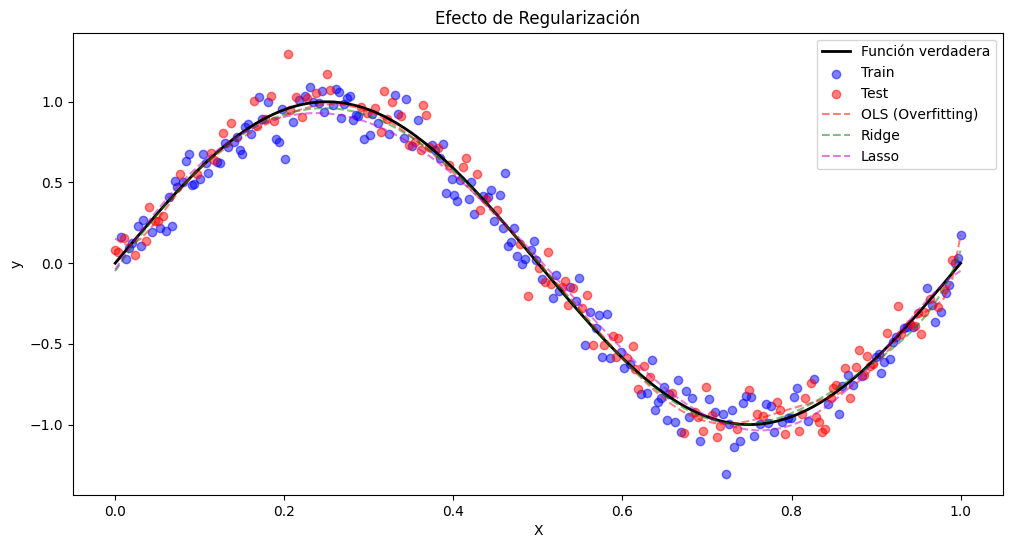

In [41]:
# Visualización comparativa

# Comparación de ajuste
X_plot = np.linspace(0,1,100).reshape(-1,1)

plt.figure(figsize=(12,6))
plt.plot(X, y_true, "k-", label = "Función verdadera", linewidth = 2)
plt.scatter(X_train, y_train, c = "blue", label = "Train", alpha = 0.5)
plt.scatter(X_test, y_test, c = "red", label = "Test", alpha = 0.5)

# Modelos
plt.plot(X_plot, model_ols.predict(X_plot), "r--", label = "OLS (Overfitting)", alpha = 0.5)
plt.plot(X_plot, model_ridge.predict(X_plot), "g--", label = "Ridge", alpha = 0.5)
plt.plot(X_plot, model_lasso.predict(X_plot), "m--", label = "Lasso", alpha = 0.5)

# Etiquetas
plt.title("Efecto de Regularización")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()

# Fin
plt.tight_layout
plt.show()

In [36]:
# Búsqueda de un alpha óptimo (Para la regresión Ridge)
param_grid = {"linear__alpha": np.logspace(-4, 4, 20)}

grid_ridge = GridSearchCV(
    estimator = model_ridge,
    param_grid = param_grid,
    cv =5,
    scoring = "neg_mean_squared_error"
)

grid_ridge.fit(X_train.reshape(-1,1), y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('poly',
                                        PolynomialFeatures(degree=15,
                                                           include_bias=False)),
                                       ('linear', Ridge())]),
             param_grid={'linear__alpha': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04])},
             scoring='neg_mean_squared_error')

In [37]:
print(f"Mejor alpha para Ridge: {grid_ridge.best_params_["linear__alpha"]}")
print(f"Mejor MSE para Ridge: {-grid_ridge.best_score_}")

Mejor alpha para Ridge: 0.0001
Mejor MSE para Ridge: 0.011223322573108563
